<a href="https://colab.research.google.com/github/LuisTT0903/Processamento-de-Sinais1/blob/main/Pr%C3%A1tica4Quest%C3%A3o2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

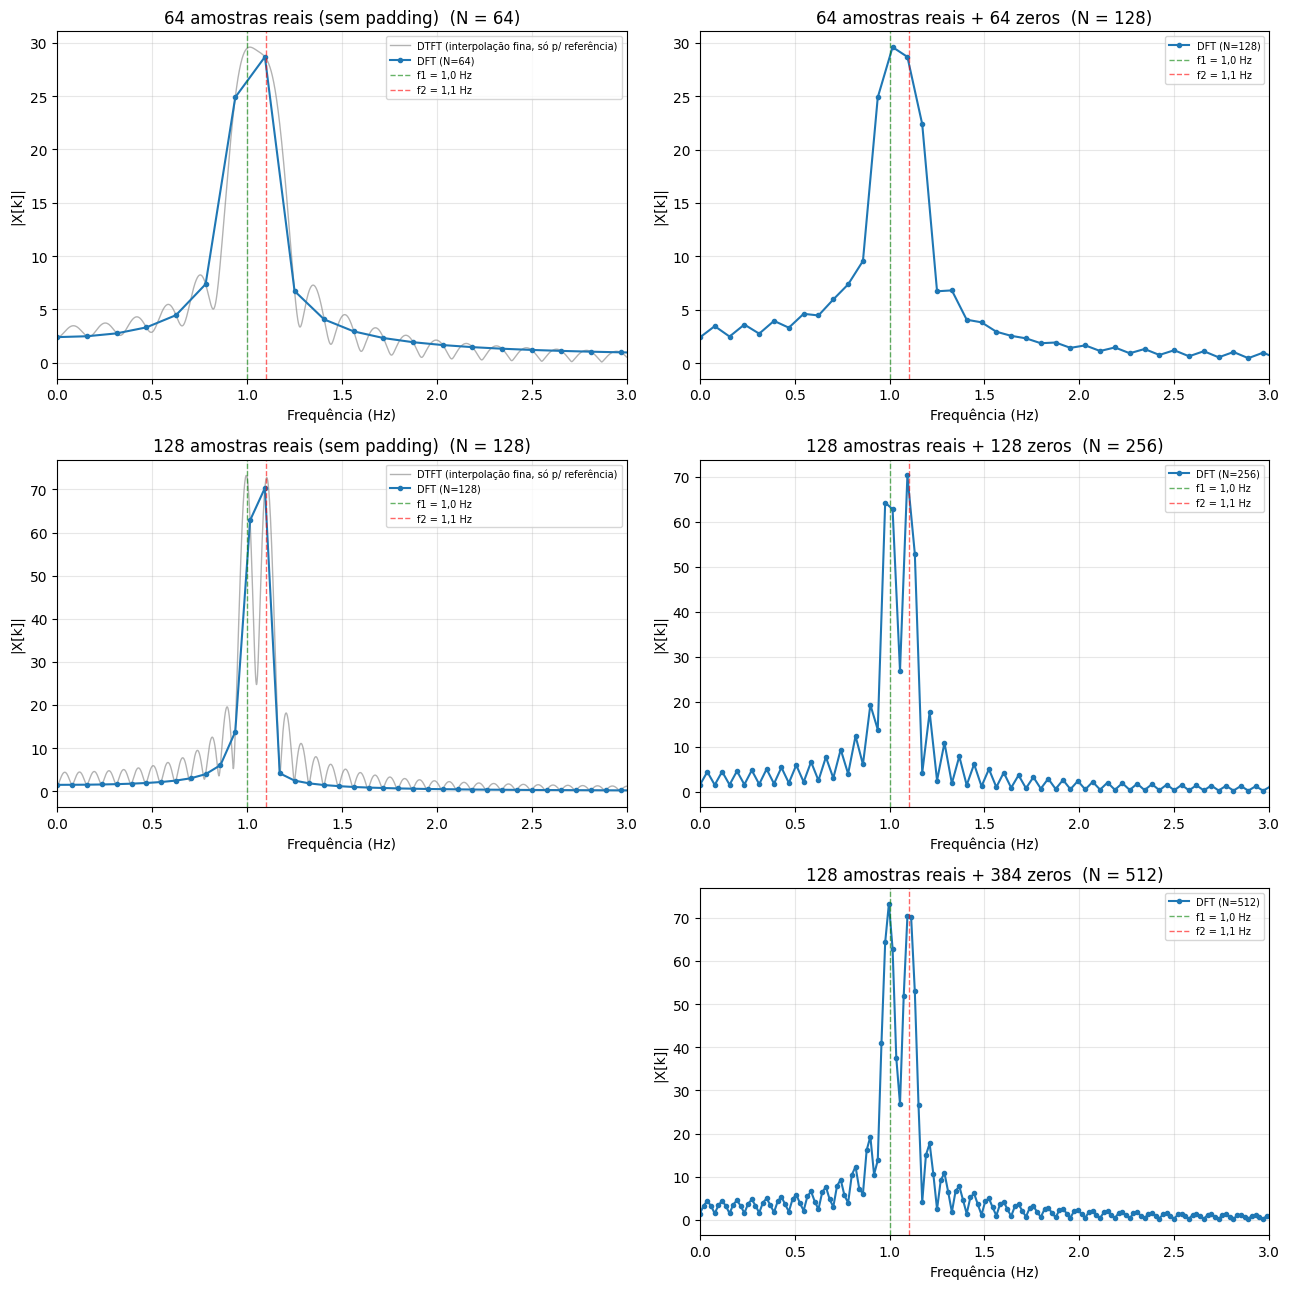

Picos locais identificados na DTFT (via interpolação bem fina, N = 8192 ), na faixa 0,7-1,4 Hz:
  Janela de 64 amostras reais  (T=6,4 s):  [(np.float64(1.014404296875), np.float64(29.592443115849193))]
  Janela de 128 amostras reais (T=12,8 s): [(np.float64(0.99609375), np.float64(73.2474257895471)), (np.float64(1.103515625), np.float64(72.75031598206779))]
  -> Com 64 amostras aparece 1 único pico (senoides fundidas); com 128 amostras aparecem 2 picos distintos, com um vale nítido entre eles.

Resolução espectral teórica (Δf = fs / N_amostras_reais):
  64 amostras reais  -> Δf = 0.1562 Hz
  128 amostras reais -> Δf = 0.0781 Hz
  Diferença entre as senoides: |f2 - f1| = 0.1000 Hz



In [1]:

import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------------
# 0. Parâmetros do sinal
# ---------------------------------------------------------------------------
fs = 10.0          # frequência de amostragem (Hz)
f1 = 1.0            # frequência da primeira senoide (Hz)
f2 = 1.1            # frequência da segunda senoide (Hz)  -> "sin(2,2*pi*t)" = sin(2*pi*1,1*t)


def gera_sinal(N, fs=fs, f1=f1, f2=f2):
    """Gera N amostras reais de x(t) = sin(2*pi*f1*t) + sin(2*pi*f2*t), t = n/fs."""
    n = np.arange(N)
    t = n / fs
    return np.sin(2 * np.pi * f1 * t) + np.sin(2 * np.pi * f2 * t)


# ---------------------------------------------------------------------------
# 1. Matriz de DFT e cálculo da DFT (sem fft)
# ---------------------------------------------------------------------------
def matriz_dft(N):
    """W[k, n] = exp(-j*2*pi*k*n/N), matriz N x N."""
    n = np.arange(N)
    k = n.reshape((N, 1))
    return np.exp(-1j * 2 * np.pi * k * n / N)


def calcula_dft(x, N=None):
    """
    Calcula a DFT de x usando a matriz de DFT.
    Se N for informado e N > len(x), aplica zero-padding até o comprimento N.
    Se N for None, usa N = len(x) (DFT "natural", sem padding).
    """
    if N is None:
        N = len(x)
    if N < len(x):
        raise ValueError("N não pode ser menor que o comprimento de x.")
    x_padded = np.zeros(N, dtype=complex)
    x_padded[: len(x)] = x
    W = matriz_dft(N)
    return W @ x_padded


def eixo_freq_hz(N, fs=fs):
    """Eixo de frequências em Hz, de 0 até fs (um período completo da DFT)."""
    return np.arange(N) * fs / N


# ---------------------------------------------------------------------------
# 2. Etapa 1: 64 amostras reais, DFT de 64 pontos
# ---------------------------------------------------------------------------
x64 = gera_sinal(64)
X64 = calcula_dft(x64)                 # DFT "natural" com N = 64
f64 = eixo_freq_hz(64)

# ---------------------------------------------------------------------------
# 3. Etapa 2: zero-padding de 64 -> 128 pontos (64 zeros adicionados)
# ---------------------------------------------------------------------------
X64_pad128 = calcula_dft(x64, N=128)   # mesmas 64 amostras reais + 64 zeros
f64_pad128 = eixo_freq_hz(128)

# ---------------------------------------------------------------------------
# 4. Etapa 3: 128 amostras REAIS (sem zero-padding)
# ---------------------------------------------------------------------------
x128 = gera_sinal(128)
X128 = calcula_dft(x128)               # DFT "natural" com N = 128
f128 = eixo_freq_hz(128)

# ---------------------------------------------------------------------------
# 5. Etapa 4: zero-padding a partir das 128 amostras reais
#    (a) +128 zeros -> N = 256      (b) +384 zeros -> N = 512
# ---------------------------------------------------------------------------
X128_pad256 = calcula_dft(x128, N=256)
f128_pad256 = eixo_freq_hz(256)

X128_pad512 = calcula_dft(x128, N=512)
f128_pad512 = eixo_freq_hz(512)

# ---------------------------------------------------------------------------
# 5b. Verificação da resolução "verdadeira": zero-padding bem denso (apenas
#     para enxergar a forma real da DTFT por trás de cada janela de sinal,
#     e localizar picos locais de forma confiável)
# ---------------------------------------------------------------------------
N_fino = 8192
X64_fino = calcula_dft(x64, N=N_fino)
X128_fino = calcula_dft(x128, N=N_fino)
f_fino = eixo_freq_hz(N_fino)


def encontra_picos(f, mag, faixa=(0.7, 1.4), limiar_rel=0.3):
    """Encontra máximos locais de mag(f) dentro de uma faixa de frequência."""
    m = (f >= faixa[0]) & (f <= faixa[1])
    ff, mm = f[m], mag[m]
    picos = []
    for i in range(1, len(mm) - 1):
        if mm[i] > mm[i - 1] and mm[i] > mm[i + 1] and mm[i] > limiar_rel * mm.max():
            picos.append((ff[i], mm[i]))
    return picos


picos_64 = encontra_picos(f_fino, np.abs(X64_fino))
picos_128 = encontra_picos(f_fino, np.abs(X128_fino))

# ---------------------------------------------------------------------------
# 6. Gráficos — magnitude da DFT em função da frequência (Hz)
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(3, 2, figsize=(13, 13))

def plota(ax, f, X, N, titulo, f_interp=None, X_interp=None):
    if f_interp is not None:
        ax.plot(f_interp, np.abs(X_interp), "-", lw=1, color="gray", alpha=0.6,
                 label="DTFT (interpolação fina, só p/ referência)")
    ax.plot(f, np.abs(X), "-o", ms=3, color="C0", label=f"DFT (N={N})")
    ax.axvline(f1, color="green", ls="--", lw=1, alpha=0.6, label="f1 = 1,0 Hz")
    ax.axvline(f2, color="red", ls="--", lw=1, alpha=0.6, label="f2 = 1,1 Hz")
    ax.set_xlim(0, 3)   # zoom na região das duas senoides (0-3 Hz)
    ax.set_xlabel("Frequência (Hz)")
    ax.set_ylabel("|X[k]|")
    ax.set_title(f"{titulo}  (N = {N})")
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

plota(axes[0, 0], f64, X64, 64, "64 amostras reais (sem padding)",
      f_fino, X64_fino)
plota(axes[0, 1], f64_pad128, X64_pad128, 128, "64 amostras reais + 64 zeros")
plota(axes[1, 0], f128, X128, 128, "128 amostras reais (sem padding)",
      f_fino, X128_fino)
plota(axes[1, 1], f128_pad256, X128_pad256, 256, "128 amostras reais + 128 zeros")
axes[2, 0].axis("off")
plota(axes[2, 1], f128_pad512, X128_pad512, 512, "128 amostras reais + 384 zeros")

plt.tight_layout()
plt.savefig("dft_resolucao_espectral.png", dpi=150)
plt.show()

print("Picos locais identificados na DTFT (via interpolação bem fina, N =",
      N_fino, "), na faixa 0,7-1,4 Hz:")
print(f"  Janela de 64 amostras reais  (T=6,4 s):  {picos_64}")
print(f"  Janela de 128 amostras reais (T=12,8 s): {picos_128}")
print(
    "  -> Com 64 amostras aparece 1 único pico (senoides fundidas); "
    "com 128 amostras aparecem 2 picos distintos, com um vale nítido entre eles.\n"
)

# ---------------------------------------------------------------------------
# 7. Resolução espectral teórica (Δf = fs / N_amostras_reais)
# ---------------------------------------------------------------------------
print("Resolução espectral teórica (Δf = fs / N_amostras_reais):")
print(f"  64 amostras reais  -> Δf = {fs/64:.4f} Hz")
print(f"  128 amostras reais -> Δf = {fs/128:.4f} Hz")
print(f"  Diferença entre as senoides: |f2 - f1| = {abs(f2-f1):.4f} Hz\n")


Comentários sobre os resultados
--------------------------------
1) Com 64 amostras reais (fs = 10 Hz), a resolução espectral é
   Δf = fs/N = 10/64 ≈ 0,156 Hz. Como a diferença entre as duas senoides é
   |f2 - f1| = 0,1 Hz, MENOR que essa resolução, os dois lóbulos se
   sobrepõem no espectro: aparece um único pico alargado em vez de dois
   picos distintos perto de 1 Hz. Não é possível distinguir claramente as
   duas componentes de frequência apenas com 64 amostras.

2) Ao aumentar a DFT para 128 pontos por zero-padding (64 amostras reais +
   64 zeros), o espectro passa a ser amostrado em uma grade mais fina
   (Δf = 10/128 ≈ 0,078 Hz entre os pontos calculados), o que deixa a curva
   com aparência mais "suave"/interpolada. Entretanto, isso NÃO melhora a
   resolução real: a informação contida no sinal continua vindo de apenas
   64 amostras (6,4 s de observação), então o formato subjacente do
   espectro (a DTFT) não muda — os dois picos continuam indistinguíveis,
   apenas mais bem interpolados. Zero-padding melhora a visualização, não a
   capacidade de separar componentes espectrais próximas.

3) Recalculando a DFT com 128 amostras REAIS (sem padding), a janela de
   observação dobra para 12,8 s e a resolução espectral melhora para
   Δf = 10/128 ≈ 0,078 Hz, que agora é MENOR que a separação de 0,1 Hz
   entre as senoides. Nesse caso, os dois picos em torno de 1 Hz e 1,1 Hz
   tornam-se visivelmente distinguíveis no espectro — a diferença em
   relação ao caso de 64 amostras não é de interpolação, mas de resolução
   espectral real, ganha por observar o sinal por mais tempo.

4) Adicionando zeros à DFT das 128 amostras reais (mais 128 zeros -> N=256,
   e depois mais 384 zeros -> N=512), o espectro fica ainda mais denso e
   "suave" — os dois picos já resolvidos ficam com contorno mais nítido e
   fica mais fácil localizar seus máximos com precisão — mas nenhum pico
   novo aparece nem a separação entre eles melhora: a resolução real
   continua sendo aquela dada pelas 128 amostras reais (Δf ≈ 0,078 Hz).

5) Conclusão: a resolução espectral verdadeira é determinada pelo número
   de amostras REAIS do sinal (equivalentemente, pela duração da janela de
   observação N/fs), pois é isso que define a largura do lóbulo principal
   da DTFT. O zero-padding (completar com zeros) apenas amostra a mesma
   DTFT em mais pontos, produzindo uma interpolação mais suave e picos
   mais fáceis de visualizar/localizar, mas sem separar componentes de
   frequência que já estivessem confundidos na DTFT original. Para
   realmente aumentar a resolução e distinguir senoides próximas, é
   necessário aumentar o número de amostras reais (observar o sinal por
   mais tempo), e não apenas aumentar N por zero-padding.
